# U-Net ISIC 2016 (Keras)

Ce notebook construit pas à pas un U-Net en Keras/TensorFlow pour segmenter les lésions du dataset ISIC 2016. Chaque étape alterne explication théorique (Markdown) et cellule code.

## Données et prétraitement
- Images dermoscopiques RGB : `dataset_ISIC/ISBI2016_ISIC_Part1_Training_Data`.
- Masques binaires : `dataset_ISIC/ISBI2016_ISIC_Part1_Training_GroundTruth` (valeurs 0/255, à binariser).
- Dimensions variables → resize uniforme (ex : 256×256), normalisation [0,1], augmentation légère (flip/rotation).

## Outils
- TensorFlow / Keras (modèle), `tf.data` (pipeline de chargement), `matplotlib` (visualisation).

## Plan de travail
1. Pipeline `tf.data` : chargement, binarisation, resize, split train/val, augmentation.
2. Modèle U-Net (encodeur-décodeur + skip connections).
3. Pertes (BCE + Dice), métriques, optimiseur.
4. Entraînement, suivi validation, checkpoints.
5. Évaluation et visualisation des prédictions.

## Étape 1 — Pipeline `tf.data` (théorie rapide)

**Objectif** : pipeline efficace pour alimenter le U-Net.

- **Lecture disque** : associer chaque image à son masque.
- **Prétraitement** : binariser les masques (0/1), normaliser les images (0–1).
- **Resize** : taille commune (ex : 256×256) pour pouvoir batcher.
- **Augmentation** (train uniquement) : flip/rotation aléatoire pour réduire l'overfitting.
- **Split** : train/val obligatoires, test optionnel pour l'évaluation finale.

On définit les chemins, quelques hyperparamètres (taille, batch), puis les fonctions de chargement/transformations pour bâtir un `tf.data.Dataset`.

---

### Comment fonctionne le resize ? (bilinéaire vs nearest)

Les images du dataset ont des tailles différentes (ex : 1024×768, 4288×2848, 576×542…). Or le réseau attend une taille fixe (256×256). Il faut donc **redimensionner** chaque image. Le problème : quand on passe de 1024×768 à 256×256, les pixels de sortie ne tombent pas pile sur les pixels d'entrée.

#### Étape 1 — Mapping de coordonnées (commun aux deux méthodes)

Pour chaque pixel $(i_{out}, j_{out})$ de l'image de sortie, on calcule sa **position correspondante** dans l'image d'entrée :

$$x_{in} = i_{out} \times \frac{H_{in}}{H_{out}}, \quad y_{in} = j_{out} \times \frac{W_{in}}{W_{out}}$$

Ce point $(x_{in}, y_{in})$ est en général **non-entier** : il tombe "entre" les pixels d'entrée.

**Exemple concret** : image 6×6 → 3×3, facteur d'échelle = 6/3 = 2.0

```
Pixel sortie (0,0) → position entrée (0×2, 0×2) = (0.0, 0.0)    ← tombe pile
Pixel sortie (1,0) → position entrée (1×2, 0×2) = (2.0, 0.0)    ← tombe pile
Pixel sortie (0,1) → position entrée (0×2, 1×2) = (0.0, 2.0)    ← tombe pile
```

Mais avec un facteur non-entier (ex : 5×4 → 3×3, facteur = 5/3 ≈ 1.667) :

```
Pixel sortie (1,1) → position entrée (1.667, 1.667)  ← entre les pixels !
```

C'est à cette étape que les deux méthodes divergent : que faire quand la coordonnée mappée tombe entre les pixels ?

#### Méthode nearest (pour les masques)

On arrondit simplement $(x_{in}, y_{in})$ à l'entier le plus proche :

$$\text{pixel sortie}(i,j) = \text{pixel entrée}\big(\text{round}(x_{in}),\; \text{round}(y_{in})\big)$$

On ne cherche **pas** parmi les 8 ou 24 voisins d'un pixel : on calcule d'abord la coordonnée exacte dans l'image source, puis on prend le pixel entier le plus proche de cette coordonnée.

```
Entrée 5×4 :                    Sortie 3×3 (nearest) :
┌────┬────┬────┬────┐
│ A  │ B  │ C  │ D  │  ← ligne 0     Sortie(0,0): map→(0.0, 0.0) → round→(0,0) = A
├────┼────┼────┼────┤                 Sortie(0,1): map→(0.0, 1.3) → round→(0,1) = B
│ E  │ F  │ G  │ H  │  ← ligne 1     Sortie(0,2): map→(0.0, 2.7) → round→(0,3) = D
├────┼────┼────┼────┤                 Sortie(1,0): map→(1.7, 0.0) → round→(2,0) = I
│ I  │ J  │ K  │ L  │  ← ligne 2     Sortie(1,1): map→(1.7, 1.3) → round→(2,1) = J
├────┼────┼────┼────┤                 ...
│ M  │ N  │ O  │ P  │  ← ligne 3
├────┼────┼────┼────┤     Résultat :  ┌───┬───┬───┐
│ Q  │ R  │ S  │ T  │                 │ A │ B │ D │
└────┴────┴────┴────┘                 │ I │ J │ L │
                                      │ Q │ R │ T │
                                      └───┴───┴───┘
```

**Pourquoi nearest pour les masques ?** Un masque contient des labels discrets (0 ou 1). Interpoler donnerait des valeurs intermédiaires (0.3, 0.7…) qui n'ont pas de sens comme étiquette de classe. Nearest garantit que chaque pixel de sortie est exactement 0 ou 1.

#### Méthode bilinéaire (pour les images)

Quand $(x_{in}, y_{in})$ tombe entre les pixels, on identifie les **4 pixels voisins** qui forment le carré 2×2 autour de ce point, puis on fait une moyenne pondérée par la distance :

```
Coordonnée mappée : (x, y) = (2.3, 1.7)

Les 4 voisins dans l'entrée :
     y=1        y=2
x=2 : pixel(2,1)  pixel(2,2)      ← les 4 coins du carré
x=3 : pixel(3,1)  pixel(3,2)        qui encadrent (2.3, 1.7)

Distances fractionnaires : dx = 0.3,  dy = 0.7
```

La formule de l'interpolation bilinéaire :

$$v = (1-dx)(1-dy) \cdot P_{00} + (1-dx) \cdot dy \cdot P_{01} + dx \cdot (1-dy) \cdot P_{10} + dx \cdot dy \cdot P_{11}$$

Avec l'exemple $(dx=0.3, dy=0.7)$ et des valeurs de pixels $P_{00}=100, P_{01}=200, P_{10}=50, P_{11}=150$ :

$$v = 0.7 \times 0.3 \times 100 + 0.7 \times 0.7 \times 200 + 0.3 \times 0.3 \times 50 + 0.3 \times 0.7 \times 150 = 152.5$$

Le pixel de sortie vaut 152.5 : une transition lisse entre ses voisins. Plus un voisin est proche de la coordonnée mappée, plus il pèse dans la moyenne.

**Pourquoi bilinéaire pour les images ?** Les intensités (couleurs RGB) sont des grandeurs continues. Interpoler entre deux pixels voisins produit un dégradé naturel, évitant les artefacts d'escalier visibles avec nearest. On n'a pas besoin de chercher parmi 24 voisins : les 4 du carré 2×2 immédiat suffisent car l'interpolation linéaire est définie par exactement 2 points par axe (2×2 = 4 points en 2D).

#### Résumé

| | Nearest | Bilinéaire |
|--|---------|-----------|
| **Étape 1** | Mapping coordonnée $(i,j)_{out} \to (x,y)_{in}$ | Idem |
| **Étape 2** | Round vers l'entier le plus proche | Moyenne pondérée des 4 voisins 2×2 |
| **Valeurs de sortie** | Copie exacte d'un pixel existant | Nouvelle valeur interpolée |
| **Usage** | Masques (labels discrets 0/1) | Images (intensités continues) |

In [ ]:
import os
import random
import tensorflow as tf
import matplotlib.pyplot as plt

# Chemins des données (adapter si besoin)
IMAGES_DIR = 'dataset_ISIC/ISBI2016_ISIC_Part1_Training_Data'
MASKS_DIR = 'dataset_ISIC/ISBI2016_ISIC_Part1_Training_GroundTruth'

# Hyperparamètres de prétraitement
IMG_SIZE = (256, 256)   # Modifier si tu préfères une autre taille
BATCH_SIZE = 8
AUTOTUNE = tf.data.AUTOTUNE

def load_image_mask(img_path, mask_path):
    """Charge image RGB et masque, renvoie tensors float32 normalisés."""
    img_bytes = tf.io.read_file(img_path)
    mask_bytes = tf.io.read_file(mask_path)
    img = tf.image.decode_jpeg(img_bytes, channels=3)
    mask = tf.image.decode_png(mask_bytes, channels=1)
    img = tf.image.convert_image_dtype(img, tf.float32)  # [0,1]
    mask = tf.cast(mask > 127, tf.float32)  # binaire 0/1
    return img, mask

def preprocess(img, mask, img_size=IMG_SIZE):
    img = tf.image.resize(img, img_size, method='bilinear')
    mask = tf.image.resize(mask, img_size, method='nearest')
    return img, mask

def augment(img, mask):
    if tf.random.uniform(()) > 0.5:
        img = tf.image.flip_left_right(img)
        mask = tf.image.flip_left_right(mask)
    if tf.random.uniform(()) > 0.5:
        img = tf.image.flip_up_down(img)
        mask = tf.image.flip_up_down(mask)
    return img, mask

def make_dataset_from_lists(img_files, mask_files, batch_size=BATCH_SIZE, img_size=IMG_SIZE, augment_data=True):
    assert len(img_files) == len(mask_files), 'Images et masques doivent correspondre'
    ds = tf.data.Dataset.from_tensor_slices((img_files, mask_files))
    ds = ds.map(lambda i, m: load_image_mask(i, m), num_parallel_calls=AUTOTUNE)
    ds = ds.map(lambda i, m: preprocess(i, m, img_size), num_parallel_calls=AUTOTUNE)
    if augment_data:
        ds = ds.map(augment, num_parallel_calls=AUTOTUNE)
    ds = ds.shuffle(buffer_size=len(img_files)).batch(batch_size).prefetch(AUTOTUNE)
    return ds

def split_paths(img_dir=IMAGES_DIR, mask_dir=MASKS_DIR, val_ratio=0.2, test_ratio=0.1, scale=0.2, shuffle_before_split=True, seed=42):
    """Retourne (train, val, test) en listes de chemins.
    - shuffle_before_split : mélange tout le dataset avant de garder la fraction scale
    - scale : fraction du dataset à conserver (ex: 0.2 = 20 %)
    """
    img_files = sorted([os.path.join(img_dir, f) for f in os.listdir(img_dir)])
    mask_files = sorted([os.path.join(mask_dir, f) for f in os.listdir(mask_dir)])

    # Mélange global (optionnel, reproductible avec seed)
    if shuffle_before_split:
        rng = random.Random(seed)
        combined = list(zip(img_files, mask_files))
        rng.shuffle(combined)
        img_files, mask_files = zip(*combined)
        img_files, mask_files = list(img_files), list(mask_files)

    # Sous-échantillonnage
    n_keep = max(1, int(len(img_files) * scale))
    img_files = img_files[:n_keep]
    mask_files = mask_files[:n_keep]

    # Split train/val/test
    n = len(img_files)
    n_train = int(n * (1 - val_ratio - test_ratio))
    n_val = int(n * val_ratio)
    train = (img_files[:n_train], mask_files[:n_train])
    val = (img_files[n_train:n_train + n_val], mask_files[n_train:n_train + n_val])
    test = (img_files[n_train + n_val:], mask_files[n_train + n_val:])
    return train, val, test


# Exemple d'utilisation (à exécuter plus tard):
# (train_img, train_mask), (val_img, val_mask), (test_img, test_mask) = split_paths(test_ratio=0.1)
# train_ds = make_dataset_from_lists(train_img, train_mask, augment_data=True)
# val_ds = make_dataset_from_lists(val_img, val_mask, augment_data=False)
# test_ds = make_dataset_from_lists(test_img, test_mask, augment_data=False)



## Fonction `augment()` — Augmentation de données

`augment(img, mask)` applique des **transformations géométriques aléatoires** identiques à l'image et au masque (alignement préservé) pour augmenter artificiellement le dataset d'entraînement.

**Transformations** (chacune avec 50 % de chance, indépendantes) :
1. **Flip horizontal** : `tf.image.flip_left_right(img)` + idem masque.
2. **Flip vertical** : `tf.image.flip_up_down(img)` + idem masque.

**4 configurations possibles** (25 % chacune) : originale, flip H, flip V, flip H+V.

**Pourquoi ?**
- Réduit le surapprentissage (le modèle voit plus de variations).
- ×4 la taille effective du dataset.
- Améliore la robustesse aux orientations.
- Transformations symétriques → structure des lésions préservée.

**Note** : appliquée uniquement sur le dataset d'**entraînement** (`augment_data=True`), pas sur la validation.

## Pipeline `make_dataset_from_lists()` — Mécanismes internes `tf.data`

La fonction construit un pipeline `tf.data.Dataset` optimisé. Voici chaque étape et son mécanisme interne :

### 1. `from_tensor_slices((img_files, mask_files))`
Crée un dataset **lazy** de paires `(chemin_image_i, chemin_masque_i)`. Les fichiers ne sont pas chargés, seuls les chemins sont stockés.

### 2. `.map(load_image_mask, num_parallel_calls=AUTOTUNE)`
Transforme chaque `(chemin_img, chemin_mask)` → `(image_tensor, mask_tensor)`. L'exécution est **paresseuse** (à la demande). `AUTOTUNE` crée plusieurs threads parallèles pour charger simultanément, ajustant automatiquement le nombre de workers selon les ressources (CPU, mémoire).

### 3. `.map(preprocess, num_parallel_calls=AUTOTUNE)`
Applique `preprocess()` en parallèle : resize bilinéaire sur les images, nearest sur les masques (cf. explication détaillée dans l'étape 1 ci-dessus).

### 4. `.shuffle(buffer_size=len(img_files))`
Maintient un **buffer** de taille `buffer_size`. À chaque demande, tire aléatoirement un élément du buffer, le retire, et insère le suivant. `buffer_size = len(img_files)` permet un mélange complet (alternative : buffer plus petit pour économiser la mémoire).

### 5. `.batch(batch_size)`
Regroupe les éléments consécutifs en tensors batchés :
- Avant : `(image: [256,256,3], mask: [256,256,1])` par élément.
- Après : `(batch_images: [B,256,256,3], batch_masks: [B,256,256,1])`.

**Contrainte** : tous les éléments doivent avoir la même shape (d'où le resize). Le batching optimise l'utilisation GPU (parallélisme matriciel).

### 6. `.prefetch(AUTOTUNE)`
Pipeline asynchrone : pendant que le GPU traite le batch actuel, le CPU prépare le suivant en arrière-plan. Réduit drastiquement les temps d'attente GPU.

### Flux complet
```
from_tensor_slices → (chemins)
  → map(load) [parallèle] → (tensors bruts, tailles variables)
  → map(preprocess) [parallèle] → (tensors 256×256, bilinéaire/nearest)
  → map(augment) [si train, parallèle] → (tensors augmentés)
  → shuffle → batch → prefetch
```

### Structure du dataset renvoyé

Chaque élément est une paire `(batch_images, batch_masks)` :
```python
for batch_images, batch_masks in train_ds:
    # batch_images.shape = [B, 256, 256, 3]
    # batch_masks.shape  = [B, 256, 256, 1]
    # batch_images[i] correspond à batch_masks[i]
```

### Pourquoi `tf.data` est efficace ?
1. **Lazy evaluation** : données chargées à la demande → économie mémoire.
2. **Parallélisme** : plusieurs éléments traités simultanément.
3. **Pipeline** : chargement, prétraitement et entraînement se chevauchent.
4. **AUTOTUNE** : ajustement automatique des ressources.

**Deux niveaux de shuffle complémentaires** :
- `shuffle_before_split` dans `split_paths` : mélange une fois la liste des fichiers avant de découper train/val/test (évite un biais d'ordre si les fichiers sont triés).
- `shuffle` dans `make_dataset_from_lists` : mélange les exemples à chaque epoch pour l'apprentissage (indispensable côté entraînement).

In [8]:
import os
import tensorflow as tf
import matplotlib.pyplot as plt
import random

# Chemins des données
IMAGES_DIR = 'dataset_ISIC/ISBI2016_ISIC_Part1_Training_Data'
MASKS_DIR = 'dataset_ISIC/ISBI2016_ISIC_Part1_Training_GroundTruth'

# Hyperparamètres de prétraitement
IMG_SIZE = (256, 256)   
BATCH_SIZE = 8
AUTOTUNE = tf.data.AUTOTUNE # valeur spéciale (généralement -1) qui indique à TensorFlow de choisir automatiquement le nombre optimal de threads/processus pour les opérations parallèles dans le pipeline tf.data.

SCALE=1.0

def load_image_mask(img_path, mask_path):
    """Charge image RGB et masque, renvoie tensors float32 normalisés."""
    img_bytes = tf.io.read_file(img_path)
    mask_bytes = tf.io.read_file(mask_path)
    img = tf.image.decode_jpeg(img_bytes, channels=3)
    mask = tf.image.decode_png(mask_bytes, channels=1)
    img = tf.image.convert_image_dtype(img, tf.float32)  # Fonction qui converti en float et normalise les valeurs (et donc les mets entre [0,1])
    mask = tf.cast(mask > 127, tf.float32)  # Converti le mask en mask binaire 0/1
    return img, mask

def preprocess(img, mask, img_size=IMG_SIZE):
    img = tf.image.resize(img, img_size, method='bilinear')
    mask = tf.image.resize(mask, img_size, method='nearest')
    return img, mask

def augment(img, mask):
    if tf.random.uniform(()) > 0.5:
        img = tf.image.flip_left_right(img)
        mask = tf.image.flip_left_right(mask)
    if tf.random.uniform(()) > 0.5:
        img = tf.image.flip_up_down(img)
        mask = tf.image.flip_up_down(mask)
    return img, mask

def make_dataset_from_lists(img_files, mask_files, batch_size=BATCH_SIZE, img_size=IMG_SIZE, augment_data=True):
    assert len(img_files) == len(mask_files), 'Images et masques doivent correspondre'
    ds = tf.data.Dataset.from_tensor_slices((img_files, mask_files))
    ds = ds.map(lambda i, m: load_image_mask(i, m), num_parallel_calls=AUTOTUNE)
    ds = ds.map(lambda i, m: preprocess(i, m, img_size), num_parallel_calls=AUTOTUNE)
    if augment_data:
        ds = ds.map(augment, num_parallel_calls=AUTOTUNE)
    ds = ds.shuffle(buffer_size=len(img_files)).batch(batch_size).prefetch(AUTOTUNE)
    return ds

def split_paths(img_dir=IMAGES_DIR, mask_dir=MASKS_DIR, val_ratio=0.2, test_ratio=0.1, scale=1.0, shuffle_before_split=True, seed=42):
    img_files = sorted([os.path.join(img_dir, f) for f in os.listdir(img_dir)])
    mask_files = sorted([os.path.join(mask_dir, f) for f in os.listdir(mask_dir)])
    n_total = len(img_files)
    n_keep = max(1, int(n_total * scale))
    img_files = img_files[:n_keep]
    mask_files = mask_files[:n_keep]

    if shuffle_before_split:
        rng = random.Random(seed)
        combined = list(zip(img_files, mask_files))
        rng.shuffle(combined)
        img_files, mask_files = zip(*combined)
        # Convertir les tuples en listes pour compatibilité avec TensorFlow
        img_files = list(img_files)
        mask_files = list(mask_files)

    n = len(img_files)
    n_train = int(n * (1 - val_ratio - test_ratio))
    n_val = int(n * val_ratio)
    train = (list(img_files[:n_train]), list(mask_files[:n_train]))
    val = (list(img_files[n_train:n_train + n_val]), list(mask_files[n_train:n_train + n_val]))
    test = (list(img_files[n_train + n_val:]), list(mask_files[n_train + n_val:]))
    return train, val, test


## Architecture U-Net avec shapes

### Vue d'ensemble

```
INPUT [256, 256, 3]
    │
    ▼ ENCODEUR (Downsampling)
    ├─ Bloc 1: Conv×2 → [256,256,64]  → MaxPool → [128,128,64]   ──skip──┐
    ├─ Bloc 2: Conv×2 → [128,128,128] → MaxPool → [64,64,128]    ──skip──┤
    ├─ Bloc 3: Conv×2 → [64,64,256]   → MaxPool → [32,32,256]    ──skip──┤
    ├─ Bloc 4: Conv×2 → [32,32,512]   → MaxPool → [16,16,512]    ──skip──┤
    │                                                                      │
    └─ Bottleneck: Conv×2 → [16,16,1024]                                  │
                                                                           │
    ▼ DÉCODEUR (Upsampling)                                                │
    ├─ Bloc 4: Up→[32,32,1024]  + skip [32,32,512]  → Concat→Conv×2 → [32,32,512]
    ├─ Bloc 3: Up→[64,64,512]   + skip [64,64,256]  → Concat→Conv×2 → [64,64,256]
    ├─ Bloc 2: Up→[128,128,256] + skip [128,128,128] → Concat→Conv×2 → [128,128,128]
    └─ Bloc 1: Up→[256,256,128] + skip [256,256,64]  → Concat→Conv×2 → [256,256,64]
    │
    ▼
OUTPUT: Conv2D(1, 1×1, sigmoid) → [256, 256, 1]  (probabilité par pixel)
```

---

### Conv2D : principe

Chaque filtre 3×3 glisse sur l'image et calcule une somme pondérée à chaque position, sur tous les canaux :

$$y_{i,j,f} = \sum_{u,v,c} w_{u,v,c,f} \cdot x_{i+u,j+v,c} + b_f$$

Avec `padding='same'`, la résolution spatiale est préservée. `Conv2D(64, 3×3)` sur un input `[256,256,3]` → `[256,256,64]` (64 feature maps, chacune détectant un motif différent : bords, textures, zones sombres…).

**Chaîne complète d'un bloc** : `Conv2D → BatchNorm → ReLU → Conv2D → BatchNorm → ReLU`

- **BatchNorm** : normalise chaque canal indépendamment (μ, σ calculés sur tout le batch), puis applique scale/shift appris (γ, β). Stabilise les activations.
- **ReLU** : `max(0, z)` — élimine les valeurs négatives, garde les activations positives.

---

### Progression des filtres dans l'encodeur

Le nombre de filtres **double** à chaque niveau (64 → 128 → 256 → 512 → 1024) pour **compenser la réduction spatiale** par MaxPool. Moins de pixels mais plus de features par pixel. Le nombre total de valeurs diminue malgré l'augmentation des filtres :

| Bloc | Résolution | Filtres | Valeurs totales |
|------|-----------|---------|----------------|
| Bloc 1 | 256×256 | 64 | 4 194 304 |
| Bloc 2 | 128×128 | 128 | 2 097 152 |
| Bloc 3 | 64×64 | 256 | 1 048 576 |
| Bloc 4 | 32×32 | 512 | 524 288 |

Pour comparaison, ResNet-50 va jusqu'à 2048 filtres, VGG-16 jusqu'à 512. On peut augmenter avec `base_filters=128` si le dataset est complexe, au prix de plus de paramètres et de risque d'overfitting.

---

### Bottleneck

```
Input: [16, 16, 512] → Conv×2 → [16, 16, 1024]
```
Point le plus compressé du réseau. Capture le **contexte global** de l'image.

---

### Concaténation (Concat) dans le décodeur

La concaténation empile les canaux de deux tensors le long de l'axe des canaux :

```
Features upsamplées [32, 32, 1024] + Skip [32, 32, 512]
→ Concat → [32, 32, 1536]
→ Conv×2 → [32, 32, 512]
```

**Pourquoi concaténer plutôt qu'additionner ?** L'addition exigerait le même nombre de canaux. La concaténation **préserve toutes les informations** des deux sources (contexte upsamplé + détails fins du skip). Les Conv2D suivantes apprennent à fusionner ces informations.

---

### Détail des blocs décodeur

| Bloc | UpSample | + Skip | Concat | → Conv×2 |
|------|----------|--------|--------|----------|
| Bloc 4 | [32,32,1024] | [32,32,512] | [32,32,1536] | [32,32,512] |
| Bloc 3 | [64,64,512] | [64,64,256] | [64,64,768] | [64,64,256] |
| Bloc 2 | [128,128,256] | [128,128,128] | [128,128,384] | [128,128,128] |
| Bloc 1 | [256,256,128] | [256,256,64] | [256,256,192] | [256,256,64] |

---

### Couche de sortie

```
[256, 256, 64] → Conv2D(1, 1×1, sigmoid) → [256, 256, 1]
```
La Conv 1×1 combine les 64 feature maps en 1 carte. Sigmoid convertit en probabilité ∈ [0,1].

---

### Récapitulatif des dimensions

| Étape | Opération | Shape In | Shape Out | Filtres |
|-------|-----------|----------|-----------|---------|
| Input | — | — | [256,256,3] | — |
| Enc. Bloc 1 | Conv×2 + MaxPool | [256,256,3] | [128,128,64] | 64 |
| Enc. Bloc 2 | Conv×2 + MaxPool | [128,128,64] | [64,64,128] | 128 |
| Enc. Bloc 3 | Conv×2 + MaxPool | [64,64,128] | [32,32,256] | 256 |
| Enc. Bloc 4 | Conv×2 + MaxPool | [32,32,256] | [16,16,512] | 512 |
| Bottleneck | Conv×2 | [16,16,512] | [16,16,1024] | 1024 |
| Déc. Bloc 4 | Up+Concat+Conv×2 | [16,16,1024] | [32,32,512] | 512 |
| Déc. Bloc 3 | Up+Concat+Conv×2 | [32,32,512] | [64,64,256] | 256 |
| Déc. Bloc 2 | Up+Concat+Conv×2 | [64,64,256] | [128,128,128] | 128 |
| Déc. Bloc 1 | Up+Concat+Conv×2 | [128,128,128] | [256,256,64] | 64 |
| Output | Conv 1×1 + Sigmoid | [256,256,64] | [256,256,1] | 1 |

---

### Skip Connections — ce qu'on sauvegarde

On sauvegarde le **tensor complet après les 2 Conv2D+BN+ReLU, AVANT le MaxPool** :

| Bloc | Shape sauvegardé | Nb. valeurs | Contenu |
|------|-----------------|-------------|---------|
| Bloc 1 | [256,256,64] | 4 194 304 | Features à résolution complète |
| Bloc 2 | [128,128,128] | 2 097 152 | Features après 2e réduction |
| Bloc 3 | [64,64,256] | 1 048 576 | Features après 3e réduction |
| Bloc 4 | [32,32,512] | 524 288 | Features après 4e réduction |

**Pourquoi avant MaxPool ?** Le MaxPool divise la résolution par 2, perdant la position précise des contours et les détails fins de texture. Les skip connections permettent au décodeur de **récupérer ces informations spatiales** pour une segmentation précise.

```python
# Encodeur
c1 = conv_block(inputs, 64)   # [256,256,64] ← sauvegardé comme skip_1
p1 = MaxPool2D(c1)             # [128,128,64] ← continue vers le bas

# Décodeur
up = UpSampling2D(...)(...)    # [256,256,128]
concat = Concat([up, skip_1])  # [256,256,192]  ← récupération des détails
```

**Pourquoi les skip connections sont importantes ?**
1. **Préservent les détails fins** (contours, textures à haute résolution).
2. **Combinent contexte + détails** : features de haut niveau du bottleneck + informations spatiales précises de l'encodeur.
3. **Sans skips**, le décodeur perdrait trop d'informations spatiales lors de l'upsampling → segmentation floue.

## Étape 2 — Autoencodeur sans skip (base de départ)

**Objectif** : implémenter un encodeur/décodeur simple (sans skip connections) pour la segmentation binaire, puis ajouter les skips après comparaison.

### Définition rapide
- **Encodeur** : Conv+BN+ReLU → MaxPool, répétés → compresse l'image, capture le contexte.
- **Décodeur** : UpSampling(nearest)+Conv+BN+ReLU, répétés → remonte la résolution.
- **Sortie** : Conv 1×1 + Sigmoid → probabilité par pixel.

### Pourquoi partir sans skip ?
- Baseline minimale pour mesurer l'impact des skip connections sur la qualité des contours.
- Moins de paramètres, plus simple à déboguer avant d'ajouter les liens latéraux.

---

### Briques de l'architecture (formules + justification)

#### Conv2D (3×3)

$$y_{i,j,c} = \sum_{u,v,c'} w_{u,v,c',c} \, x_{i+u,j+v,c'} + b_c$$

**Pourquoi deux Conv2D consécutives par bloc ?**

| Aspect | 1 Conv 3×3 | 2 Conv 3×3 |
|--------|-----------|-----------|
| Champ réceptif | 3×3 | 5×5 (effectif : 3+3−1) |
| Paramètres | 9 poids/filtre | 18 poids/filtre (< 25 pour un kernel 5×5) |
| Non-linéarités | 1 (ReLU) | 2 (compositions → motifs plus complexes) |
| Capacité | Features simples (bords) | Features hiérarchiques (bords → formes, coins, courbes) |

Deux convolutions offrent un bon compromis entre capacité, efficacité et simplicité. Au-delà de 2-3 convolutions par bloc, les gains diminuent (diminishing returns) et le risque de surapprentissage augmente.

Le champ réceptif, c'est "combien de pixels de l'image originale influencent un pixel de sortie".
    - Avec 1 Conv 3×3 : chaque pixel de sortie voit une fenêtre 3×3 de l'entrée. Simple.
    - Avec 2 Conv 3×3 empilées : la 2e conv regarde une fenêtre 3×3… mais chaque pixel de cette fenêtre a lui-même déjà "vu" une fenêtre 3×3 de l'image originale. Donc le pixel final voit plus large dans l'image d'origine.

---

#### BatchNormalization (BN)

$$\hat{z} = \frac{z - \mu}{\sqrt{\sigma^2 + \epsilon}}, \quad y = \gamma \hat{z} + \beta$$

Pour un tensor `[batch_size, H, W, channels]`, BN normalise **chaque canal indépendamment** en calculant μ et σ sur **tout le batch** (d'où le nom "Batch" Normalization).

**Exemple** : pour `[8, 256, 256, 64]`, canal 0 → 8 × 256 × 256 = 524 288 valeurs pour estimer μ₀ et σ₀. Puis normalisation `ẑ = (z − μ) / (σ + ε)`, et scale/shift appris `y = γẑ + β`.

**Pourquoi BN est important ?**

1. **Réduit l'Internal Covariate Shift** : pendant l'entraînement, les poids changent à chaque itération, modifiant la distribution des activations. BN stabilise cette distribution (μ ≈ 0, σ ≈ 1) pour que la couche suivante reçoive des inputs prévisibles.

2. **Permet des learning rates plus élevés** : sans BN, les gradients peuvent exploser ou s'évanouir selon la distribution des activations, forçant un LR faible (ex : 0.0001). Avec BN, gradients stables → LR 10–100× plus grand (ex : 0.01) → convergence plus rapide.

3. **Réduit la sensibilité aux initialisations** : poids trop grands → activations qui explosent ; trop petits → activations proches de 0. BN normalise dans les deux cas, rendant l'entraînement robuste à l'initialisation.

4. **Régularisation légère** : les statistiques μ, σ varient d'un batch à l'autre, ajoutant du bruit bénéfique qui réduit le surapprentissage (complémentaire au Dropout, mais plus léger).

**Comparaison avec d'autres normalisations** :

| Type | Calcul μ/σ sur | Usage typique |
|------|---------------|--------------|
| **Batch Norm** | Tout le batch | CNNs (notre cas) |
| Layer Norm | Tous les canaux d'une image | RNNs, Transformers |
| Instance Norm | Un canal d'une image | Style transfer |
| Group Norm | Groupe de canaux d'une image | Petits batches |

**Entraînement vs inférence** : pendant l'entraînement, μ/σ sont calculés sur le batch courant ; en inférence, on utilise les **moyennes mobiles** accumulées pendant l'entraînement (plus stable).

---

#### ReLU (Rectified Linear Unit)

$$\text{ReLU}(z) = \max(0, z)$$

**Pourquoi ReLU ?**

1. **Simplicité computationnelle** : juste une comparaison, vs calculs exponentiels pour Sigmoid/Tanh.
2. **Résout le vanishing gradient** : dérivée = 1 pour z > 0 (vs Sigmoid/Tanh dont la dérivée → 0 pour les valeurs extrêmes). Gradient après 10 couches : Sigmoid ≈ 0.25¹⁰ ≈ 0.0000005 vs ReLU = 1¹⁰ = 1.
3. **Sparsité naturelle** : ~50 % de zéros → représentations efficaces, régularisation implicite.
4. **Non-saturation** pour les valeurs positives (contrairement à Sigmoid/Tanh qui plafonnent).
5. **Bonne compatibilité avec BN** : BN centre autour de 0 → ReLU garde la moitié positive.

**Problème du "Dying ReLU"** : un neurone qui produit toujours des valeurs négatives "meurt" (gradient = 0 permanent). Mitigé dans notre U-Net par BN (qui recentre) et les skip connections (voies alternatives pour les gradients). Alternatives (Leaky ReLU, ELU) possibles mais ReLU reste le meilleur compromis simplicité/performance.

---

#### MaxPool 2×2

$$\text{MaxPool}(x)_{i,j,c} = \max_{u,v \in \{0,1\}} x_{2i+u, 2j+v, c}$$

Réduit la résolution spatiale par 2, augmente le champ réceptif, apporte une invariance locale à la translation.

---

#### UpSampling2D (nearest)

$$y_{2i+u, 2j+v, c} = x_{i,j,c} \quad (u,v \in \{0,1\})$$

Chaque pixel est dupliqué en un bloc 2×2, doublant la résolution.

```
[10, 20]      [10, 10, 20, 20]
[30, 40]  →   [10, 10, 20, 20]
              [30, 30, 40, 40]
              [30, 30, 40, 40]
```

**Comparaison des méthodes d'upsampling** :

| Méthode | Vitesse | Qualité | Paramètres | Usage |
|---------|---------|---------|-----------|-------|
| **Nearest** | Très rapide | Basique | 0 | Masques, features (notre choix) |
| Bilinéaire | Rapide | Bonne (lisse) | 0 | Images RGB |
| Bicubique | Lent | Excellente | 0 | Images haute qualité |
| Transposed Conv | Moyen | Excellente | Appris | Upsampling adaptatif |

**Pourquoi nearest dans U-Net ?** Les détails fins sont récupérés via les **skip connections**, pas via l'upsampling. Nearest est rapide, simple, sans artefacts.

---

#### Sortie Sigmoid 1×1

$$\hat{p}_{i,j} = \sigma(z_{i,j}) = \frac{1}{1 + e^{-z_{i,j}}}$$

La Conv 1×1 combine les 64 feature maps en 1 carte (`[256,256,64] → [256,256,1]`). Sigmoid transforme en probabilité ∈ [0,1].

**Pourquoi Sigmoid et pas ReLU ?**
- Sigmoid produit des probabilités bornées [0,1] → interprétable ("80 % de chance que ce pixel soit lésion").
- Compatible avec BCE : `log(ŷ)` et `log(1−ŷ)` bien définis. ReLU (non borné) rendrait BCE instable.
- Seuil naturel à 0.5 pour binariser le masque.
- Gradient maximal en zone d'incertitude (σ = 0.5), minimal quand le réseau est sûr → apprentissage efficace.
- Pour 2 classes, Sigmoid est équivalent à Softmax mais plus simple.

In [9]:
from tensorflow.keras import layers, models

def conv_block(x, filters, kernel_size=3, activation="relu"):
    x = layers.Conv2D(filters, kernel_size, padding="same", kernel_initializer="he_normal")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation(activation)(x)
    x = layers.Conv2D(filters, kernel_size, padding="same", kernel_initializer="he_normal")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation(activation)(x)
    return x

def build_autoencoder(input_shape=(256, 256, 3), base_filters=64, activation="relu"):
    inputs = layers.Input(shape=input_shape)

    # Encodeur (pas de skip conservé ici)
    c1 = conv_block(inputs, base_filters)
    p1 = layers.MaxPool2D((2, 2))(c1)

    c2 = conv_block(p1, base_filters * 2)
    p2 = layers.MaxPool2D((2, 2))(c2)

    c3 = conv_block(p2, base_filters * 4)
    p3 = layers.MaxPool2D((2, 2))(c3)

    c4 = conv_block(p3, base_filters * 8)
    p4 = layers.MaxPool2D((2, 2))(c4)

    # Bottleneck
    bn = conv_block(p4, base_filters * 16)

    # Décodeur sans skip : on remonte simplement
    u4 = layers.UpSampling2D((2, 2))(bn)
    d4 = conv_block(u4, base_filters * 8)

    u3 = layers.UpSampling2D((2, 2))(d4)
    d3 = conv_block(u3, base_filters * 4)

    u2 = layers.UpSampling2D((2, 2))(d3)
    d2 = conv_block(u2, base_filters * 2)

    u1 = layers.UpSampling2D((2, 2))(d2)
    d1 = conv_block(u1, base_filters)

    outputs = layers.Conv2D(1, 1, activation="sigmoid")(d1)

    model = models.Model(inputs, outputs, name="Autoencoder_no_skips")
    return model

# Exemple d'instanciation (à exécuter plus tard)
# model = build_autoencoder(input_shape=(256, 256, 3), base_filters=64)
# model.summary()


## Étape 3 — Pertes et métriques (BCE + Dice)

- **BCE (Binary Cross-Entropy)** : pénalise chaque pixel selon l'écart entre prédiction et label 0/1. Bonne base "pixelwise".
- **Dice** (coefficient de recouvrement) : mesure le chevauchement prédit/vrai. Dice loss = 1 − Dice ; utile quand la classe "lésion" est minoritaire.
- **BCE + Dice combinés** : couvre l'erreur pixel par pixel (BCE) et l'équilibre global des régions (Dice) → plus stable en segmentation.

In [ ]:
import tensorflow as tf
from tensorflow.keras import backend as K

def dice_coefficient(y_true, y_pred, smooth=1e-6):
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    return (2. * intersection + smooth) / (K.sum(y_true_f) + K.sum(y_pred_f) + smooth)

def dice_loss(y_true, y_pred):
    return 1.0 - dice_coefficient(y_true, y_pred)

def bce_dice_loss(y_true, y_pred):
    bce = tf.keras.losses.binary_crossentropy(y_true, y_pred)
    return bce + dice_loss(y_true, y_pred)

# Exemple de compilation (à adapter au modèle que tu utilises)
# model = build_autoencoder(input_shape=(256, 256, 3), base_filters=64)
# model.compile(
#     optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
#     loss=bce_dice_loss,
#     metrics=[dice_coefficient, 'binary_accuracy']
# )


## Étape 4 — Entraînement (fit) et suivi

- Instanciation et compilation du modèle (autoencodeur sans skips pour l'instant).
- Entraînement sur `train_ds`, validation sur `val_ds`, suivi des métriques (Dice, binary_accuracy).
- Callbacks : **EarlyStopping** (éviter l'overfit), **ModelCheckpoint** (sauvegarder le meilleur modèle).

## Suivi des pertes et arrêt anticipé

- Courbes train/val (loss + Dice) pour vérifier l'apprentissage sans surapprentissage.
- **EarlyStopping** : stoppe quand `val_loss` ne s'améliore plus après N epochs (patience), restaure les meilleurs poids.
- **ModelCheckpoint** : sauvegarde automatiquement le meilleur modèle (selon `val_loss`).

## Optimiseur Adam et descente de gradient en pratique

### Rappel : SGD et Adam (formules)

- **SGD** : $w \leftarrow w - \alpha \cdot g_t$, avec $g_t = \nabla_w \mathcal{L}_t$.
- **Adam** ajoute deux moyennes mobiles exponentielles :
  - $m_t = \beta_1 m_{t-1} + (1-\beta_1) g_t$ (momentum, moyenne 1er ordre)
  - $v_t = \beta_2 v_{t-1} + (1-\beta_2) g_t^2$ (variance approx., 2e ordre)
- **Corrections de biais** : $\hat{m}_t = m_t / (1-\beta_1^t)$, $\hat{v}_t = v_t / (1-\beta_2^t)$.
- **Mise à jour** : $w \leftarrow w - \alpha \cdot \hat{m}_t / (\sqrt{\hat{v}_t} + \epsilon)$.
- **Effet** : combine momentum ($m_t$) et pas adaptatif ($v_t$) → plus stable que SGD, moins sensible au choix du learning rate.

---

### Comment le calcul est parallélisé en pratique ?

#### Le problème : 31 millions de paramètres à mettre à jour

Notre U-Net a ~31M poids. À chaque itération, il faut :
1. **Forward pass** : propager un batch d'images à travers le réseau → prédictions.
2. **Loss** : comparer prédictions vs masques → un scalaire (la perte).
3. **Backward pass** : calculer le gradient $\partial \mathcal{L} / \partial w$ pour chacun des 31M poids.
4. **Update** : appliquer la règle Adam sur chaque poids.

Faire ça séquentiellement (pixel par pixel, poids par poids) serait inutilisable. C'est là que le **GPU** et le **batching** interviennent.

#### Niveau 1 — Le batch : parallélisme sur les exemples

Le batch (ex : 8 images) n'est pas traité image par image. Les 8 images sont empilées en un **seul tensor** `[8, 256, 256, 3]` et toutes les opérations s'appliquent sur ce tensor d'un coup.

Concrètement, une Conv2D sur un batch ne fait pas :
```
pour chaque image i dans [0..7]:
    sortie[i] = convolution(image[i], filtre)    ← séquentiel, lent
```

Elle fait :
```
sortie[0..7] = convolution_batchée(images[0..7], filtre)   ← une seule opération parallèle
```

Le GPU traite les 8 images **simultanément** car l'opération est la même pour chacune (mêmes filtres, même padding). C'est le même principe que le SIMD (Single Instruction, Multiple Data).

#### Niveau 2 — La convolution : parallélisme spatial et par filtre

Une Conv2D(64, 3×3) sur un input `[8, 256, 256, 3]` effectue en réalité :
- **256 × 256** = 65 536 positions spatiales
- **× 64** filtres
- **× 8** images du batch
- = **33 554 432** opérations de "fenêtre 3×3×3 → somme pondérée"

Chacune de ces opérations est **indépendante** des autres (le calcul en position (i,j) ne dépend pas du calcul en position (i',j')). Le GPU peut donc les exécuter en parallèle.

**Comment ?** En pratique, TensorFlow/cuDNN transforme la convolution en une **multiplication de matrices** (algorithme im2col) :

```
1. im2col : réarrange les patches 3×3×3 de l'input en lignes d'une matrice
   → matrice A de shape [8×256×256, 3×3×3] = [524288, 27]

2. Les 64 filtres sont empilés en colonnes d'une matrice
   → matrice W de shape [27, 64]

3. La convolution entière = un seul produit matriciel :
   Sortie = A × W → [524288, 64]

4. Reshape → [8, 256, 256, 64]
```

Un GPU (comme la T4 qu'on utilise) possède **2560 cœurs CUDA** qui calculent ce produit matriciel en parallèle. La T4 fait ~65 TFLOPS en float16 : elle peut effectuer 65 000 milliards d'opérations par seconde.

#### Niveau 3 — Le backward pass : même parallélisme, en sens inverse

La rétropropagation calcule $\partial \mathcal{L} / \partial w$ pour chaque poids. La bonne nouvelle : le gradient d'une convolution est **aussi une convolution** (sur le gradient de la sortie), donc le même mécanisme im2col + produit matriciel s'applique.

```
Forward :  Sortie = Input ★ Filtre          (★ = convolution)
Backward : ∂L/∂Filtre = Input^T ★ ∂L/∂Sortie    ← gradient des poids
           ∂L/∂Input  = ∂L/∂Sortie ★ Filtre^T    ← gradient à propager
```

Chaque couche calcule ses gradients en parallèle via un produit matriciel sur GPU, puis les passe à la couche précédente. L'ensemble du backward est ~2× le coût du forward.

#### Niveau 4 — L'update Adam : opération élément-par-élément

Une fois tous les gradients calculés, la mise à jour Adam s'applique **indépendamment à chaque poids** :

```
Pour chacun des 31M poids (en parallèle sur GPU) :
    m[i] = β₁ · m[i] + (1-β₁) · g[i]
    v[i] = β₂ · v[i] + (1-β₂) · g[i]²
    w[i] = w[i] - α · m̂[i] / (√v̂[i] + ε)
```

Il n'y a aucune dépendance entre les poids : le GPU traite les 31M updates simultanément en quelques microsecondes.

#### Résumé : une itération complète

```
Batch [8, 256, 256, 3]
  │
  ├─ Forward pass (GPU, parallèle sur batch × spatial × filtres)
  │   Chaque Conv2D = un produit matriciel géant via im2col
  │   → Prédictions [8, 256, 256, 1]
  │
  ├─ Loss (GPU, parallèle sur les 8×256×256 pixels)
  │   → Scalaire L
  │
  ├─ Backward pass (GPU, même parallélisme que forward, ~2× le coût)
  │   → Gradients pour chacun des 31M poids
  │
  └─ Adam update (GPU, 31M opérations indépendantes en parallèle)
      → Poids mis à jour
```

**C'est pour cela qu'un GPU est indispensable** : un CPU (8-16 cœurs) ferait ces mêmes opérations ~50-100× plus lentement car il ne peut paralléliser que sur quelques cœurs, alors que le GPU en a des milliers.

#### Pourquoi le batch size compte ?

| Batch size | Parallélisme GPU | Estimation du gradient | RAM GPU |
|-----------|-----------------|----------------------|---------|
| 1 | Sous-utilise le GPU (peu de données à paralléliser) | Très bruité (1 seul exemple) | Faible |
| 8 | Bon compromis | Raisonnablement stable | Modéré |
| 32 | GPU bien saturé | Stable | Élevé |
| 256 | GPU saturé, pas de gain supplémentaire | Très stable mais généralise parfois moins bien | Très élevé |

Le batch size est un compromis entre saturation du GPU (plus = plus rapide par image), qualité du gradient (plus = plus stable), et mémoire disponible.

Epoch 1/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 11s/step - binary_accuracy: 0.7652 - dice_coefficient: 0.5564 - loss: 0.9411 

16/16 ━━━━━━━━━━━━━━━━━━━━ 202s 12s/step - binary_accuracy: 0.8374 - dice_coefficient: 0.6372 - loss: 0.7616 - val_binary_accuracy: 0.3126 - val_dice_coefficient: 0.4610 - val_loss: 4.8652
Epoch 2/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 11s/step - binary_accuracy: 0.9064 - dice_coefficient: 0.7566 - loss: 0.4987 

16/16 ━━━━━━━━━━━━━━━━━━━━ 185s 12s/step - binary_accuracy: 0.9004 - dice_coefficient: 0.7563 - loss: 0.5159 - val_binary_accuracy: 0.4849 - val_dice_coefficient: 0.3154 - val_loss: 1.8184
Epoch 3/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 11s/step - binary_accuracy: 0.9192 - dice_coefficient: 0.7714 - loss: 0.4489 

16/16 ━━━━━━━━━━━━━━━━━━━━ 186s 12s/step - binary_accuracy: 0.9176 - dice_coefficient: 0.7812 - loss: 0.4361 - val_binary_accuracy: 0.6913 - val_dice_coefficient: 0.2147 - val_loss: 1.4652
Epoch 4/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10s/step - binary_accuracy: 0.9226 - dice_coefficient: 0.8179 - loss: 0.3897 

16/16 ━━━━━━━━━━━━━━━━━━━━ 177s 11s/step - binary_accuracy: 0.9241 - dice_coefficient: 0.8081 - loss: 0.4003 - val_binary_accuracy: 0.6893 - val_dice_coefficient: 0.2287 - val_loss: 1.4371
Epoch 5/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 11s/step - binary_accuracy: 0.9160 - dice_coefficient: 0.8074 - loss: 0.4205 

16/16 ━━━━━━━━━━━━━━━━━━━━ 186s 12s/step - binary_accuracy: 0.9214 - dice_coefficient: 0.8076 - loss: 0.4068 - val_binary_accuracy: 0.6978 - val_dice_coefficient: 0.2658 - val_loss: 1.4339
Epoch 6/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 11s/step - binary_accuracy: 0.9399 - dice_coefficient: 0.8370 - loss: 0.3238 

16/16 ━━━━━━━━━━━━━━━━━━━━ 184s 11s/step - binary_accuracy: 0.9367 - dice_coefficient: 0.8360 - loss: 0.3401 - val_binary_accuracy: 0.7473 - val_dice_coefficient: 0.3887 - val_loss: 1.1839
Epoch 7/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 11s/step - binary_accuracy: 0.9385 - dice_coefficient: 0.8188 - loss: 0.3623 

16/16 ━━━━━━━━━━━━━━━━━━━━ 184s 11s/step - binary_accuracy: 0.9376 - dice_coefficient: 0.8333 - loss: 0.3389 - val_binary_accuracy: 0.7811 - val_dice_coefficient: 0.4932 - val_loss: 1.0700
Epoch 8/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 11s/step - binary_accuracy: 0.9348 - dice_coefficient: 0.8472 - loss: 0.3201 

16/16 ━━━━━━━━━━━━━━━━━━━━ 184s 11s/step - binary_accuracy: 0.9370 - dice_coefficient: 0.8421 - loss: 0.3247 - val_binary_accuracy: 0.8344 - val_dice_coefficient: 0.6491 - val_loss: 0.7835
Epoch 9/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 183s 11s/step - binary_accuracy: 0.9436 - dice_coefficient: 0.8488 - loss: 0.3099 - val_binary_accuracy: 0.8411 - val_dice_coefficient: 0.6518 - val_loss: 0.7855
Epoch 10/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 174s 11s/step - binary_accuracy: 0.9463 - dice_coefficient: 0.8584 - loss: 0.2871 - val_binary_accuracy: 0.8417 - val_dice_coefficient: 0.6580 - val_loss: 0.8099


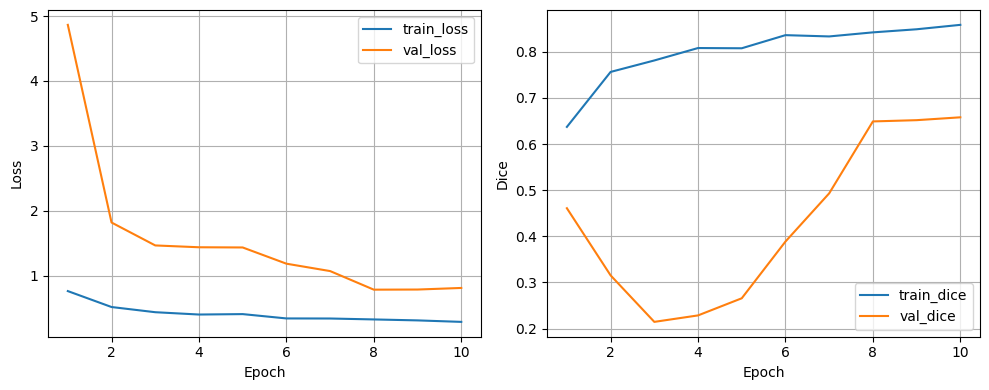

In [ ]:
# Instancier le modèle (autoencodeur sans skip pour l’instant)
model = build_autoencoder(input_shape=(256, 256, 3), base_filters=64)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=bce_dice_loss,
    metrics=[dice_coefficient, 'binary_accuracy']
)

# Préparer les datasets (exemple)
(train_img, train_mask), (val_img, val_mask), (test_img, test_mask) = split_paths(
    val_ratio=0.2, test_ratio=0.1, scale=0.2, shuffle_before_split=True, seed=42
)
train_ = make_dataset_from_lists(train_img, train_mask, augment_data=True)
val_ds   = make_dataset_from_lists(val_img, val_mask, augment_data=False)


# Callbacks (adapter patience/chemin si besoin)
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        patience=8, monitor='val_loss', restore_best_weights=True
    ),
    tf.keras.callbacks.ModelCheckpoint(
        'autoencoder_no_skips_best.h5', save_best_only=True, monitor='val_loss'
    ),
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=callbacks
)

# Plot des courbes loss et dice
import matplotlib.pyplot as plt

def plot_history(history):
    hist = history.history
    epochs = range(1, len(hist['loss']) + 1)

    plt.figure(figsize=(10,4))
    plt.subplot(1,2,1)
    plt.plot(epochs, hist['loss'], label='train_loss')
    plt.plot(epochs, hist['val_loss'], label='val_loss')
    plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend(); plt.grid(True)

    if 'dice_coefficient' in hist:
        plt.subplot(1,2,2)
        plt.plot(epochs, hist['dice_coefficient'], label='train_dice')
        plt.plot(epochs, hist['val_dice_coefficient'], label='val_dice')
        plt.xlabel('Epoch'); plt.ylabel('Dice'); plt.legend(); plt.grid(True)

    plt.tight_layout()
    plt.show()

plot_history(history)



## Évaluation finale (test)

- Modèle gelé, mesure de la loss et métriques sur le test set (données jamais vues en train/val).
- `model.evaluate(test_ds)` → loss + Dice + binary_accuracy.
- Estime la performance de généralisation.

In [14]:
# Si pas déjà fait plus haut :
# (train_img, train_mask), (val_img, val_mask), (test_img, test_mask) = split_paths(
#     val_ratio=0.2, test_ratio=0.1, scale=0.2, shuffle_before_split=True, seed=42
# )

test_ds = make_dataset_from_lists(test_img, test_mask, augment_data=False)

test_results = model.evaluate(test_ds, return_dict=True)
print("Test loss:", test_results["loss"])
print("Test Dice:", test_results["dice_coefficient"])
print("Test binary_accuracy:", test_results["binary_accuracy"])



3/3 ━━━━━━━━━━━━━━━━━━━━ 7s 2s/step - binary_accuracy: 0.8793 - dice_coefficient: 0.7253 - loss: 0.6148
Test loss: 0.6148133873939514
Test Dice: 0.7253332734107971
Test binary_accuracy: 0.8793461918830872


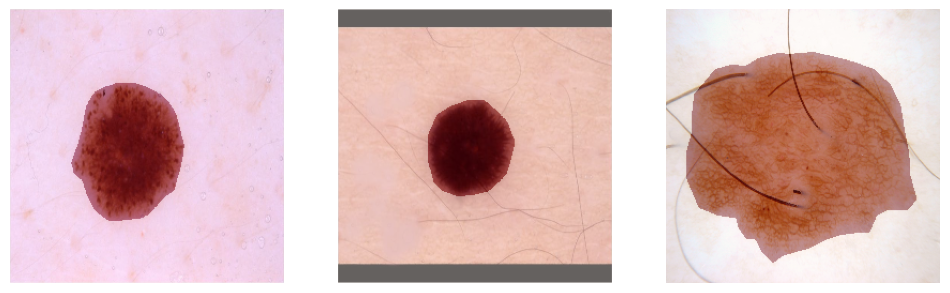

2026-01-22 17:41:25.179046: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [15]:
import matplotlib.pyplot as plt

def show_batch(ds, n=3):
    for imgs, masks in ds.take(1):
        imgs, masks = imgs.numpy(), masks.numpy()
        plt.figure(figsize=(4*n, 4))
        for i in range(n):
            plt.subplot(1, n, i+1)
            plt.imshow(imgs[i])
            plt.imshow(masks[i].squeeze(), alpha=0.4, cmap='Reds')
            plt.axis('off')
        plt.show()

show_batch(train_ds, n=3)


1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step


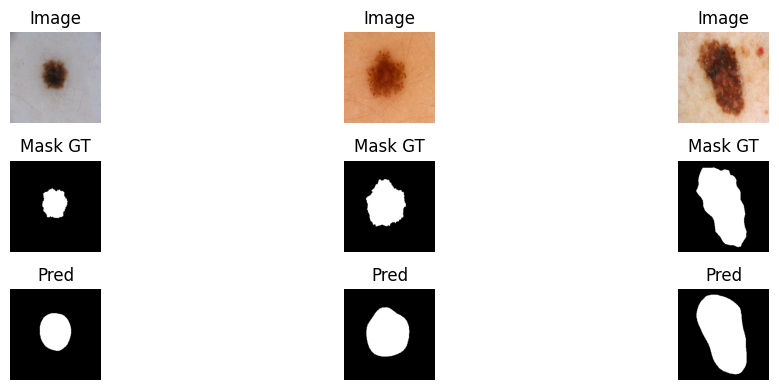

In [16]:
def show_predictions(ds, model, n=3, thr=0.5):
    for imgs, masks in ds.take(1):
        preds = model.predict(imgs)
        imgs, masks, preds = imgs.numpy(), masks.numpy(), preds
        plt.figure(figsize=(4*n, 4))
        for i in range(n):
            plt.subplot(3, n, i+1)
            plt.imshow(imgs[i]); plt.axis('off'); plt.title('Image')

            plt.subplot(3, n, n+i+1)
            plt.imshow(masks[i].squeeze(), cmap='gray'); plt.axis('off'); plt.title('Mask GT')

            plt.subplot(3, n, 2*n+i+1)
            plt.imshow((preds[i].squeeze() > thr).astype('float'), cmap='gray')
            plt.axis('off'); plt.title('Pred')
        plt.tight_layout()
        plt.show()
        break

show_predictions(val_ds, model, n=3)
